# Bitcoin Price Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.graph_objs import candlestick
import yfinance as yf
import talib
from utils.read_prices import read_parquet
from utils.metrics import Metrics

In [2]:
## from January 2016 - December 2020

btc_2016_2020 = yf.download(tickers='BTC-USD',
                     start='2016-01-01',
                     end='2020-12-31',
                     auto_adjust=True,
                     multi_level_index=False)

btc_2016_2020.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600


In [3]:
## from january 2021 - december 2025

## for backtesting purposes

btc_2021_2025 = yf.download(tickers='BTC-USD',
                     start='2021-01-01',
                     end='2025-12-31',
                     auto_adjust=True,
                     multi_level_index=False)

btc_2021_2025.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782


In [4]:
btc_2016_2020.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [5]:
btc_2016_2020.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2016-01-01 to 2020-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1826 non-null   float64
 1   High    1826 non-null   float64
 2   Low     1826 non-null   float64
 3   Open    1826 non-null   float64
 4   Volume  1826 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.6 KB


In [6]:
btc_2016_2020.describe()

,Close,High,Low,Open,Volume
count,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03
mean,6118.848393,6259.301537,5945.559781,6103.383477,1.164336e+10
std,4703.295017,4820.207635,4535.488914,4674.882347,1.376704e+10
min,364.330994,374.950012,354.914001,365.072998,2.851400e+07
25%,1187.825043,1206.202515,1172.047485,1184.262512,3.338000e+08
50%,6413.792480,6534.830078,6314.354980,6412.694824,5.302091e+09
75%,9208.396973,9360.110352,9035.487061,9209.826904,1.898423e+10
max,28840.953125,28937.740234,27360.089844,27360.089844,7.415677e+10


In [7]:
btc_2021_2025.describe()

,Close,High,Low,Open,Volume
count,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03
mean,54408.228931,55440.815712,53249.015332,54377.884361,3.717743e+10
std,29461.698618,29865.535897,29021.845342,29456.676425,2.305696e+10
min,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09
25%,29397.714844,29952.029297,28975.560547,29376.455078,2.133027e+10
50%,46453.566406,47510.726562,45235.816406,46415.898438,3.180847e+10
75%,69122.335938,70046.273438,67535.132812,69020.546875,4.721185e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


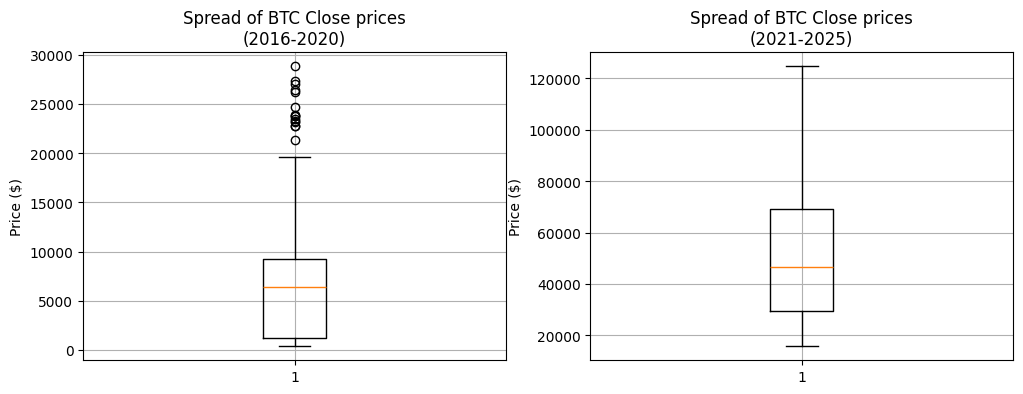

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].boxplot(btc_2016_2020["Close"])
ax[0].set_title("Spread of BTC Close prices\n(2016-2020)")
ax[0].set_ylabel("Price ($)")
ax[0].set_xlabel('')
ax[0].grid(.4)

ax[1].boxplot(btc_2021_2025["Close"])
ax[1].set_title("Spread of BTC Close prices\n(2021-2025)")
ax[1].set_ylabel("Price ($)")
ax[1].set_xlabel('')
ax[1].grid(.4)

plt.show()

In [9]:
btc_2016_2020[btc_2016_2020["Close"] > 20000].shape[0] ## how many days the price closed above the whisker in the plot above

15

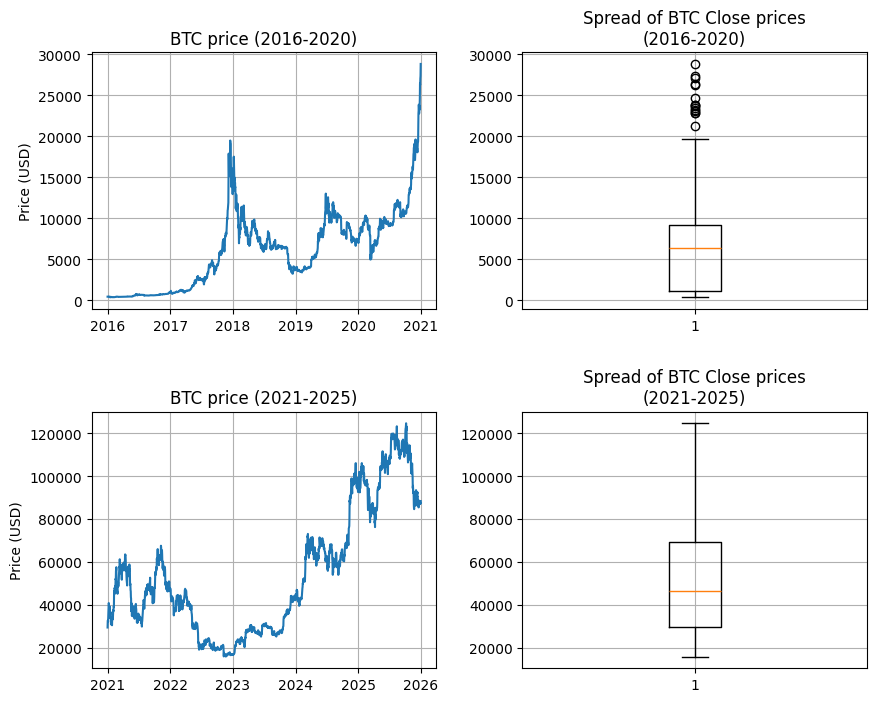

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(10,8), gridspec_kw={'hspace': 0.40, 'wspace': 0.25})

ax[0,0].plot(btc_2016_2020["Close"])
ax[0,0].set_title("BTC price (2016-2020)")
ax[0,0].set_ylabel("Price (USD)")
ax[0,0].grid(.4)

ax[0,1].boxplot(btc_2016_2020["Close"])
ax[0,1].set_title("Spread of BTC Close prices\n(2016-2020)")
ax[0,1].set_xlabel('')
ax[0,1].grid(.4)

ax[1,0].plot(btc_2021_2025["Close"])
ax[1,0].set_title("BTC price (2021-2025)")
ax[1,0].set_ylabel("Price (USD)")
ax[1,0].grid(.4)

ax[1,1].boxplot(btc_2021_2025["Close"])
ax[1,1].set_title("Spread of BTC Close prices\n(2021-2025)")
ax[1,1].set_xlabel('')
ax[1,1].grid(.4)

plt.show()

In [11]:
btc_2016_2020.to_parquet(path='../price_ranges/btc_price_2016-2020.parquet')
btc_2021_2025.to_parquet(path='../price_ranges/btc_price_2021-2025.parquet')

In [12]:
btc_2016_2020_prices = pd.read_parquet('../price_ranges/btc_price_2016-2020.parquet')
btc_2016_2020_prices.head()

,Close,High,Low,Open,Volume
Date,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600


In [13]:
btc_2021_2025_prices = read_parquet('../price_ranges/btc_price_2021-2025.parquet')
btc_2021_2025_prices.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225


## US Interest Rates

Using data from the Federal Reserve Bank of St. Louis we will add the interest rate as another feature to the bitcoin prices to see if there are any interesting price movements/strategy movements when factoring in the interest rate.

In [14]:
fred_df = read_parquet('../price_ranges/federal_funds_rate_ammended.parquet')
fred_df.head()

,DFF
observation_date,
2016-01-01,0.20
2016-01-02,0.20
2016-01-03,0.20
2016-01-04,0.36
2016-01-05,0.36


In [15]:
fred_2016_2020 = fred_df.loc['2016-01-01':'2020-12-31']
fred_2021_2025 = fred_df.loc['2021-01-01':'2025-12-31'] ## use for backtest dataset
fred_2016_2020

,DFF
observation_date,
2016-01-01,0.20
2016-01-02,0.20
2016-01-03,0.20
2016-01-04,0.36
2016-01-05,0.36
...,...
2020-12-27,0.09
2020-12-28,0.09
2020-12-29,0.09


In [16]:
btc_2016_2020_prices['interest_rate'] = fred_2016_2020['DFF'].values[:-1]
btc_2021_2025_prices['interest_rate'] = fred_2021_2025['DFF'].values[:-1]


In [17]:
btc_2016_2020_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2016-01-01 to 2020-12-30
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          1826 non-null   float64
 1   High           1826 non-null   float64
 2   Low            1826 non-null   float64
 3   Open           1826 non-null   float64
 4   Volume         1826 non-null   int64  
 5   interest_rate  1826 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 99.9 KB


In [18]:
btc_2021_2025_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1825 entries, 2021-01-01 to 2025-12-30
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          1825 non-null   float64
 1   High           1825 non-null   float64
 2   Low            1825 non-null   float64
 3   Open           1825 non-null   float64
 4   Volume         1825 non-null   int64  
 5   interest_rate  1825 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 99.8 KB


In [19]:
btc_2016_2020_prices.to_parquet('../price_ranges/btc_price_2016-2020.parquet')
btc_2021_2025_prices.to_parquet('../price_ranges/btc_price_2021-2025.parquet')

Using Peng Liu's book *Quantitative Trading Strategies Using Python: Technical Analysis, Statistical Testing, and Machine Learning* as a guide, we'll calculate a few metrics that will be helpful to assess trading strategies as well as how to implement a buy-n-hold and trend-following strategy.

Another strategy called pairs trading is outlined in the book, but as of now with this project, we will forego that strategy and look at the previous two mentioned.

In [20]:
fig = make_subplots(1,1)

fig.add_trace(
    go.Scatter(x=btc_2016_2020_prices.index, y=btc_2016_2020_prices['Close'],
            name='Close Price'),
            row=1,
            col=1
            )

fig.show()

We can see that the price of bitcoin over the last 5 years has seen many fluctuations. Because of the volatility there is opportunity in capitalizing on these massive price swings.

### Returns

Since we are looking at daily price movement our period will be 365 (prior period will be yesterday). If we were looking at monthly price data, the period would be 12 (prior period would be the month prior). And so on and so on.

The daily differences in prices from the day prior can be expressed like so:

In [21]:
# returns = df.iloc[:, :-1].pct_change().dropna(axis=0) + 1
returns = btc_2016_2020_prices['Close'].pct_change() + 1 ## +1 indicated as the multiplier
returns.head(10)

Date
2016-01-01         NaN
2016-01-02    0.997937
2016-01-03    0.992093
2016-01-04    1.007163
2016-01-05    0.997389
2016-01-06    0.993391
2016-01-07    1.067450
2016-01-08    0.989481
2016-01-09    0.987602
2016-01-10    1.000849
Name: Close, dtype: float64

In [22]:
btc_2016_2020_prices['returns'] = btc_2016_2020_prices['Close'].pct_change() + 1
btc_2016_2020_prices['log_returns'] = np.log(btc_2016_2020_prices['returns'])

btc_2021_2025_prices["returns"] = btc_2021_2025_prices["Close"].pct_change() + 1
btc_2021_2025_prices["log_returns"] = np.log(btc_2021_2025_prices["returns"])

In [23]:
btc_2016_2020_prices["returns"].describe()

count    1825.000000
mean        1.003077
std         0.039170
min         0.628305
25%         0.988796
50%         1.002180
75%         1.017551
max         1.252472
Name: returns, dtype: float64

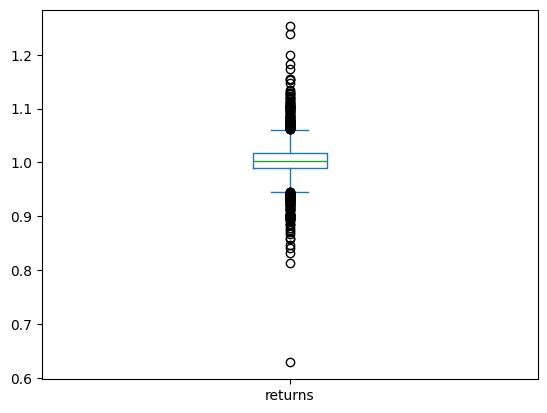

In [24]:
btc_2016_2020_prices["returns"].plot(kind="box")
plt.show()

In [25]:
btc_2021_2025_prices["returns"].describe()

count    1824.000000
mean        1.001072
std         0.030601
min         0.840253
25%         0.986817
50%         0.999992
75%         1.014917
max         1.187465
Name: returns, dtype: float64

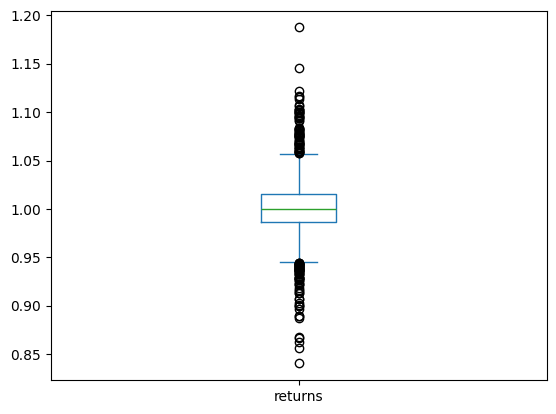

In [26]:
btc_2021_2025_prices["returns"].plot(kind="box")
plt.show()

In [27]:
btc_2016_2020_prices.to_parquet('../price_ranges/btc_price_2016-2020.parquet')
btc_2021_2025_prices.to_parquet("../price_ranges/btc_price_2021-2025.parquet")

### EMA

In [28]:
alpha = .1 ## higher degree of smoothing

EWM_1 = 'EWM_'+str(alpha)

btc_2016_2020_prices[EWM_1] = btc_2016_2020_prices["Close"].ewm(alpha=alpha, adjust=False).mean()
btc_2021_2025_prices[EWM_1] = btc_2021_2025_prices['Close'].ewm(alpha=alpha, adjust=False).mean()

btc_2021_2025_prices.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1
Date,,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,NaN,NaN,29374.152344
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,1.093726,0.089590,29649.463867
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,1.020380,0.020175,29962.719824
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,0.975288,-0.025022,30163.639248
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,1.063197,0.061280,30546.518292


In [29]:
alpha = .5 ## more susceptible to recent price changes

EWM_2 = 'EWM_'+str(alpha)

btc_2016_2020_prices[EWM_2] = btc_2016_2020_prices['Close'].ewm(alpha=alpha, adjust=False).mean()
btc_2021_2025_prices[EWM_2] = btc_2021_2025_prices['Close'].ewm(alpha=alpha, adjust=False).mean()

btc_2021_2025_prices.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1,EWM_0.5
Date,,,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,NaN,NaN,29374.152344,29374.152344
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,1.093726,0.089590,29649.463867,30750.709961
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,1.020380,0.020175,29962.719824,31766.366699
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,0.975288,-0.025022,30163.639248,31869.140381
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,1.063197,0.061280,30546.518292,32930.785034


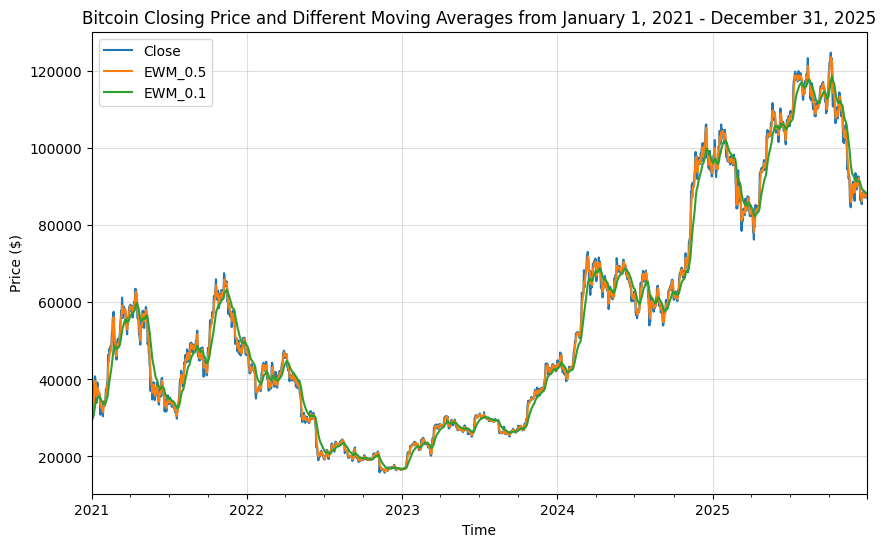

In [30]:
btc_2021_2025_prices[['Close', 'EWM_0.5', 'EWM_0.1']].plot(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Price ($)')
plt.title('Bitcoin Closing Price and Different Moving Averages from January 1, 2021 - December 31, 2025')
plt.grid(alpha=.4)
plt.show()

### Backtesting the Trend-Following Strategy

Calculating the annualized return and volatility, the sharpe ratio, and the max drawdown we will use these metrics to backtest 2025 as a whole.

The optimization problem of finding the short and long term moving averages that give the best terminal return, annualized return, sharpe ratio, etc. can be explored through experimentation as well as looking at the *Quantitative Trading Strategies using Python*.

In [31]:
back_test = btc_2021_2025_prices.copy()
back_test.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1,EWM_0.5
Date,,,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,NaN,NaN,29374.152344,29374.152344
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,1.093726,0.089590,29649.463867,30750.709961
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,1.020380,0.020175,29962.719824,31766.366699
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,0.975288,-0.025022,30163.639248,31869.140381
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,1.063197,0.061280,30546.518292,32930.785034


In [32]:
back_test.tail()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1,EWM_0.5
Date,,,,,,,,,,
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,3.64,1.000764,0.000764,88497.655911,87395.516518
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,3.64,1.005736,0.005719,88428.105945,87598.836384
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,3.64,1.000384,0.000384,88368.878944,87717.336161
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849,3.64,0.992057,-0.007975,88245.805112,87427.738393
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225,3.64,1.014827,0.014718,88264.237882,87928.935603


In [33]:
back_test['returns'] = back_test['Close'].pct_change() + 1
back_test['log_returns'] = np.log(back_test['returns'])

In [34]:
sma_long_span = 200

sma_short_span = 50

short_ma = 'SMA-'+str(sma_short_span)

long_ma = 'SMA-'+str(sma_long_span)

back_test[long_ma] = back_test['Close'].rolling(sma_long_span).mean()

back_test[short_ma] = back_test['Close'].rolling(sma_short_span).mean()

back_test.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1,EWM_0.5,SMA-200,SMA-50
Date,,,,,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,NaN,NaN,29374.152344,29374.152344,NaN,NaN
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,1.093726,0.089590,29649.463867,30750.709961,NaN,NaN
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,1.020380,0.020175,29962.719824,31766.366699,NaN,NaN
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,0.975288,-0.025022,30163.639248,31869.140381,NaN,NaN
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,1.063197,0.061280,30546.518292,32930.785034,NaN,NaN


In [35]:
### Since generating the trading signal requires that both moving averages are available at each time point, we remove the rows with any NA value in the DataFrame using the dropna() method

# back_test.dropna(inplace=True)

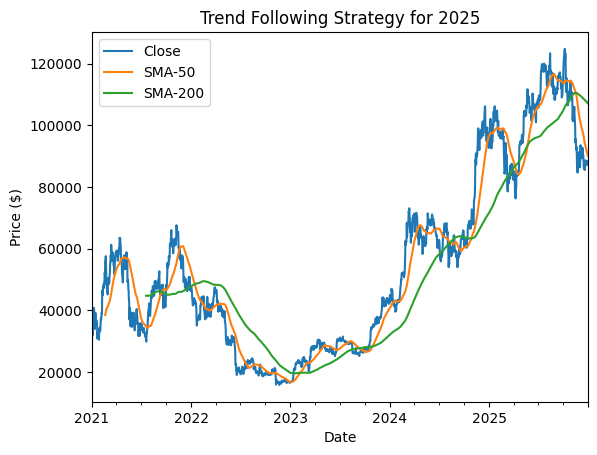

In [36]:
back_test[['Close', 'SMA-50', 'SMA-200']].plot(kind='line')

plt.ylabel('Price ($)')
plt.title('Trend Following Strategy for 2025')
plt.show()

In [37]:
## if we buy one bitcoin at the beggining of the year how much will it be worth at the end?

# back_test_2025['log_return_buy_n_hold'] = np.log(back_test_2025['Close']['BTC-USD']).diff()

In [38]:
## trading signals

## buy signal
back_test['signal'] = np.where(back_test['SMA-50'] > back_test['SMA-200'], 1, 0)

## short signal
back_test['signal'] = np.where(back_test['SMA-50'] < back_test['SMA-200'], -1, back_test['signal'])

back_test.dropna(inplace=True)

In [39]:
back_test['log_return_trend_follow'] = back_test['signal'] * back_test['log_returns']

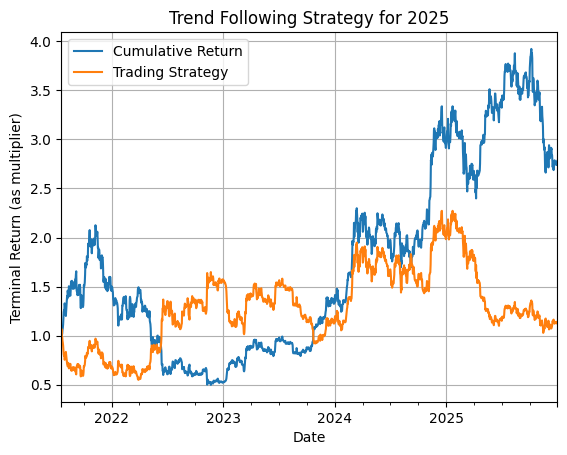

In [40]:
np.exp(back_test['log_returns'].cumsum()).plot(kind='line', label='Cumulative Return')
np.exp(back_test['log_return_trend_follow'].cumsum()).plot(kind='line', label='Trading Strategy')

plt.ylabel('Terminal Return (as multiplier)')
plt.title('Trend Following Strategy for 2025')
plt.grid(.4)
plt.legend()
plt.show()

We can see that the price of bitcoin during this period was trending down. By implementing a simple trading strategy, using 50 and 200-day moving averages, there was an opportunity to harbor ones portfolio towards the later end of 2025 where the terminal return of the trading strategy looked to beat a buy-and-hold strategy of ~ 12%.

In [41]:
## terminal return

backtest_bnh_terminal_return = Metrics.terminal_return(back_test['log_returns']) * 100

backtest_tf_terminal_return = Metrics.terminal_return(back_test['log_return_trend_follow']) * 100

print(f"2025 backtested buy-n-hold terminal return: {backtest_bnh_terminal_return:.2f}%\n")

print(f"2025 backtested trend-following terminal return: {backtest_tf_terminal_return:.2f}%")

2025 backtested buy-n-hold terminal return: 178.11%

2025 backtested trend-following terminal return: 12.39%


In [42]:
## annulaized returns buy-n-hold

annualized_return_buy_n_hold = Metrics.annualized_return(back_test['log_returns'])

annualized_return_trend_follow = Metrics.annualized_return(back_test['log_return_trend_follow'])

print(f"2025 backtested buy-n-hold annualized return: {annualized_return_buy_n_hold:.4f}\n")

print(f"2025 backtested trend-following annualized return: {annualized_return_trend_follow:.4f}")

2025 backtested buy-n-hold annualized return: 0.2581

2025 backtested trend-following annualized return: 0.0266


Again the trend-following strategy looks to outperform the buy-n-hold strategy.

In [43]:
## annualized volatility

bnh_vol = Metrics.volatility(back_test['returns']+1)
tf_vol = Metrics.volatility(back_test['log_return_trend_follow']+1)

# annualized_volatility_bnh_2022 = (np.exp(back_test_2025['log_returns'])-1).std()*(365**0.5)
annualized_vol_bnh_2022 = Metrics.annualized_volatility(365, bnh_vol)

# annualized_volatility_tf_2022 = (np.exp(back_test_2025['log_return_trend_follow'])-1).std()*(365**0.5)
annualized_vol_tf_2022 = Metrics.annualized_volatility(365, tf_vol)

print(f"2025 backtested buy-n-hold volatility: {annualized_vol_bnh_2022:.4f}\n")

print(f"2025 backtested trend-following volatility: {annualized_vol_tf_2022:.4f}")

# annualized_volatility_bnh_2022, annualized_volatility_tf_2022

2025 backtested buy-n-hold volatility: 0.5324

2025 backtested trend-following volatility: 0.5327


In [44]:
## sharpe ratio
risk_free_rate = 0.015

backtest_sharpe_ratio_bnh = (annualized_vol_bnh_2022 - risk_free_rate) / annualized_vol_bnh_2022

backtest_sharpe_ratio_tf = (annualized_vol_tf_2022 - risk_free_rate) / annualized_vol_tf_2022

print(f"2025 backtested buy-n-hold sharpe ratio: {backtest_sharpe_ratio_bnh:.4f}\n")

print(f"2025 backtested trend-following sharpe ratio: {backtest_sharpe_ratio_tf:.4f}")

2025 backtested buy-n-hold sharpe ratio: 0.9718

2025 backtested trend-following sharpe ratio: 0.9718


In [45]:
## max drawdown

backtest_drawdown_bnh = Metrics.drawdown(back_test['log_returns'], 5000)['Drawdown'].max()

backtest_drawdown_tf = Metrics.drawdown(back_test['log_return_trend_follow'], 5000)['Drawdown'].max()

print(f"2025 backtested buy-n-hold max drawdown: {backtest_drawdown_bnh:.4f}\n")

print(f"2025 backtested trend-following max drawdown: {backtest_drawdown_tf:.4f}")

2025 backtested buy-n-hold max drawdown: 8142.2544

2025 backtested trend-following max drawdown: 6222.5461


In [46]:
backtest_drawdown_bnh/5000, backtest_drawdown_tf/5000

(np.float64(1.6284508746240065), np.float64(1.2445092125867063))

The buy-n-hold strategy over the year 2025 could have resulted in a 34% loss from the high that year, whereas the trend-following strategy could have resulted in 26% loss.

## Momentum Strategies

Most simple time series momentum strategy where you buy the stock if the last return was positive and sell the stock if the sign was negative.


In [47]:
btc_2016_2020_prices["close_sign"] = np.sign(btc_2016_2020_prices['log_returns'])

btc_2016_2020_prices["strat_log_returns"] = btc_2016_2020_prices['log_returns'] * btc_2016_2020_prices["close_sign"].shift(1)
btc_2016_2020_prices["strat_returns"] = btc_2016_2020_prices['returns'] * btc_2016_2020_prices["close_sign"].shift(1)

In [48]:
btc_2016_2020_prices.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,EWM_0.1,EWM_0.5,close_sign,strat_log_returns,strat_returns
Date,,,,,,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN,434.334015,434.334015,NaN,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065,434.244412,433.886002,-1.0,NaN,NaN
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938,433.821070,431.948494,-1.0,0.007938,-0.992093
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137,433.748063,432.519749,1.0,-0.007137,-1.007163
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615,433.569256,432.239870,-1.0,-0.002615,0.997389


In [49]:
.36/5000, 0.000072

(7.2e-05, 7.2e-05)

In [50]:
btc_2016_2020_prices.dropna(inplace=True)

In [51]:
btc_2016_2020_prices["trades"] = btc_2016_2020_prices["close_sign"].diff().fillna(0) != 0

In [52]:
btc_2016_2020_prices["trades"].sum()

np.int64(945)

In [53]:
cost = np.log(.36)
cost = .36/5000
cost

7.2e-05

In [54]:
btc_2016_2020_prices["strat_returns"]

Date
2016-01-03   -0.992093
2016-01-04   -1.007163
2016-01-05    0.997389
2016-01-06   -0.993391
2016-01-07   -1.067450
                ...   
2020-12-26    1.071853
2020-12-27    0.993769
2020-12-28   -1.030927
2020-12-29    1.010250
2020-12-30    1.054034
Name: strat_returns, Length: 1824, dtype: float64

In [55]:
np.exp(btc_2016_2020_prices["strat_returns"].where(btc_2016_2020_prices["trades"])).cumsum()*5000

Date
2016-01-03             NaN
2016-01-04    1.826269e+03
2016-01-05    1.538223e+04
2016-01-06             NaN
2016-01-07    1.710165e+04
                  ...     
2020-12-26             NaN
2020-12-27    7.123863e+06
2020-12-28    7.125646e+06
2020-12-29             NaN
2020-12-30             NaN
Name: strat_returns, Length: 1824, dtype: float64

In [56]:
strat[trades] -= cost

NameError: name 'strat' is not defined

In [ ]:
strat[trades]

Date
2016-01-04   -0.007209
2016-01-05   -0.002687
2016-01-07   -0.065344
2016-01-08   -0.010646
2016-01-10   -0.000921
                ...   
2020-12-22   -0.042149
2020-12-23   -0.023111
2020-12-24   -0.021130
2020-12-27   -0.006323
2020-12-28   -0.030530
Name: log_returns, Length: 945, dtype: float64

In [ ]:
strat

Date
2016-01-01         NaN
2016-01-02         NaN
2016-01-03    0.007938
2016-01-04   -0.007209
2016-01-05   -0.002687
                ...   
2020-12-26    0.069389
2020-12-27   -0.006323
2020-12-28   -0.030530
2020-12-29    0.010198
2020-12-30    0.052625
Name: log_returns, Length: 1826, dtype: float64

In [ ]:
np.exp(strat.cumsum())*5000

Date
2016-01-01             NaN
2016-01-02             NaN
2016-01-03     5039.847842
2016-01-04     5003.645636
2016-01-05     4990.219367
                  ...     
2020-12-26    16008.580819
2020-12-27    15907.678080
2020-12-28    15429.354748
2020-12-29    15587.511114
2020-12-30    16429.774481
Name: log_returns, Length: 1826, dtype: float64

In [ ]:
np.exp(btc_2016_2020_prices['log_returns'].cumsum())*5000

Date
2016-01-15      4233.394304
2016-01-16      4503.028205
2016-01-17      4442.176166
2016-01-18      4498.752045
2016-01-19      4417.193660
                  ...      
2020-12-26    307188.804297
2020-12-27    305274.559695
2020-12-28    314715.674533
2020-12-29    317941.621957
2020-12-30    335121.438481
Name: log_returns, Length: 1812, dtype: float64

In [ ]:
len(strat[trades]) * cost

0.06804

In [ ]:
(np.exp(strat.cumsum()) * 5000) - 340.2

Date
2016-01-01             NaN
2016-01-02             NaN
2016-01-03     4699.647842
2016-01-04     4663.445636
2016-01-05     4650.019367
                  ...     
2020-12-26    15668.380819
2020-12-27    15567.478080
2020-12-28    15089.154748
2020-12-29    15247.311114
2020-12-30    16089.574481
Name: log_returns, Length: 1826, dtype: float64

In [ ]:
strat[trades].cumsum()[-1].item(), strat.cumsum()[-1].item()

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_1776/1383604039.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



(-22.44305938855934, 1.1896572934464762)

## Mean Reversion Strategy

In [ ]:
btc_2016_2020_prices

,Close,High,Low,Open,Volume,interest_rate,EWM_0.1,EWM_0.5
Date,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,29374.152344,29374.152344
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,29649.463867,30750.709961
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,29962.719824,31766.366699
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,30163.639248,31869.140381
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,30546.518292,32930.785034
...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,3.64,88497.655911,87395.516518
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,3.64,88428.105945,87598.836384
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,3.64,88368.878944,87717.336161


In [ ]:
df_3 = btc_2016_2020_prices[['Close', 'log_returns', 'interest_rate']].copy()

In [ ]:
df_3['SMA'] = df_3['Close'].rolling(25).mean()
df_3['Distance'] = df_3['Close'] - df_3['SMA']

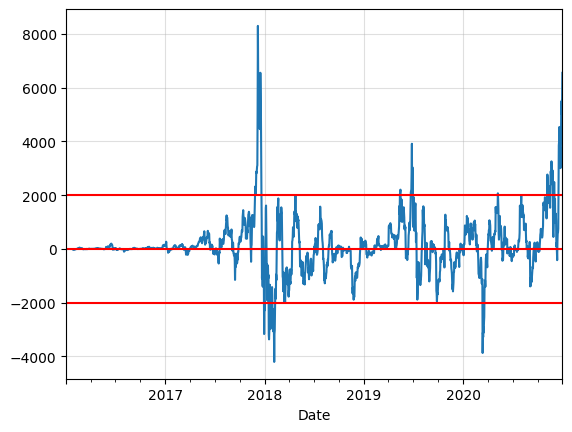

In [ ]:
df_3['Distance'].plot(kind='line')
plt.axhline(0, color='r')
plt.axhline(2000, color='r')
plt.axhline(-2000, color='r')
plt.grid(alpha=.4)
plt.show()

In [ ]:
SMA = 25
thresholds = np.linspace(1500, 2500, 5)
# thresholds = 2000
threshold_strategies = [df_3['log_returns']]

for i in thresholds:
    df = df_3.copy()

    df['SMA'] = df['Close'].rolling(SMA).mean()
    df['distance'] = df['Close'] - df['SMA']
    df.dropna()

    ## strategy of buying/selling given the threshold
    df['position'] = np.where(df['distance'] > i, -1, np.nan)

    df['position'] = np.where(df['distance'] < -i,
                                1, df['position'])

    df['position'] = np.where(df['distance'] * df['distance'].shift(1) < 0, 0, df['position'])

    df['position'] = df['position'].ffill().fillna(0)

    strategy = df['position'].shift(1) * df['log_returns']
    strategy = strategy.dropna()

    threshold_strategies.append(strategy)

In [ ]:
thresholds = thresholds.tolist()

In [ ]:
thresholds.append(0)

In [ ]:
thresholds.sort()

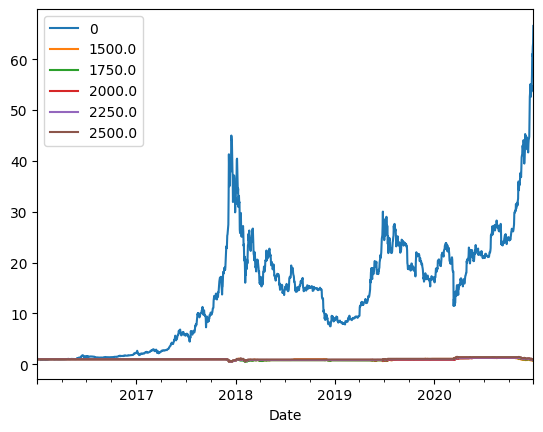

In [ ]:
for (strategy,
    threshold,
    # linestyle
    ) \
        in zip(
    threshold_strategies,
    thresholds, 
    # ['-', '--', '--', '--', '--', '--', '--']
    ):
    np.exp(strategy.cumsum()).plot(kind='line',
                                   label=f"{threshold}",
                                #    linestyle=linestyle
                                   )

plt.legend()
plt.show()

### Technical Indicators

The TA-Lib library provides many different indicators. We will look at a few of them to add to our price dataset.

In [ ]:
btc_2016_2020_prices['roc'] = talib.ROC(btc_2016_2020_prices['Close'])
btc_2016_2020_prices['atr'] = talib.ATR(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])
btc_2016_2020_prices['di+'] = talib.PLUS_DI(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])
btc_2016_2020_prices['di-'] = talib.MINUS_DI(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])

In [ ]:
btc_2016_2020_prices.head()

In [ ]:
btc_2016_2020_prices[['roc']].plot(kind='line')
plt.title("ROC Indicator")
plt.grid(.4)
plt.show()

### July 2021 - December 2022

In [ ]:
july_2021_december_2022_df = btc_2021_2025_prices.loc['2021-07-01': '2022-12-31']

KeyError: 'log_returns'

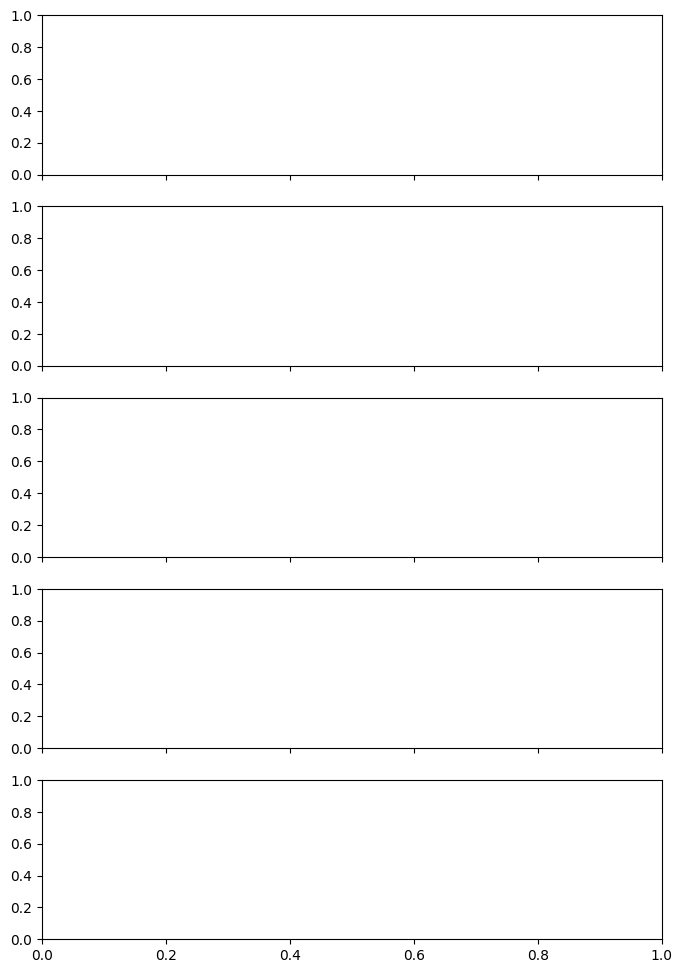

In [ ]:
fig, ax = plt.subplots(5, 1, sharex=True, figsize=(8,12))

macd_line, signal_line, macd_hist = talib.MACD(july_2021_december_2022_df['Close'])

# adx_line = talib.ADX(july_2021_december_2022_df['High'], july_2021_december_2022_df['Low'], july_2021_december_2022_df['Close'])

############
ax[0].plot(np.exp(july_2021_december_2022_df['log_returns']).cumprod(), label='Buy-n-Hold')
ax[0].plot(np.exp(july_2021_december_2022_df['log_return_trend_follow']).cumprod(), label='Trend-Follow')
ax[0].grid(alpha=.3)
ax[0].set_ylabel('Price Multiplier per Strategy')
ax[0].set_title('Cumulative return of different trading strategies')
ax[0].legend()

############
ax[1].plot(july_2021_december_2022_df['interest_rate'], label='US Interest Rate')
ax[1].grid(alpha=.3)
ax[1].set_ylabel('Percent')
ax[1].set_title('US Interest Rate')
ax[1].legend()

############
ax[2].plot(july_2021_december_2022_df['Close'], label='Close Price')
ax[2].plot(july_2021_december_2022_df['SMA-50'], label='50 day moving average')
ax[2].plot(july_2021_december_2022_df['SMA-200'], label='200-day moving average')
ax[2].grid(alpha=.3)
ax[2].set_ylabel('Price')
ax[2].set_title('Close price with moving averages')
ax[2].legend()

###########
ax[3].plot(macd_line, label='MACD Line')
ax[3].plot(signal_line, label='Signal')
ax[3].bar(july_2021_december_2022_df.index, macd_hist)
ax[3].set_title('MACD')
ax[3].grid(alpha=.3)
ax[3].legend()

############
ax[4].plot(talib.RSI(july_2021_december_2022_df['Close']), label='RSI')
ax[4].set_title('RSI')
ax[4].grid(alpha=.3)
ax[4].legend()

############
# ax[5].plot(adx_line, label='ADX')
# ax[5].set_title('ADX')
# ax[5].grid(alpha=.3)
# ax[5].legend()

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

In [ ]:
atr = talib.ATR(btc_df['High'], btc_df['Low'], btc_df['Close'])

In [ ]:
atr.plot(kind='line')
plt.grid(alpha=.3)
plt.show()